In [1]:
# 1. Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 2. Load our perfectly cleaned and processed dataset
file_path = '../data/processed/credit_risk_processed.csv'
df = pd.read_csv(file_path)

# 3. Separate features (X) and target variable (y)
# y is what we want to predict (loan_status: 0 = good, 1 = bad)
# X is every column EXCEPT our target
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# 4. Perform Train/Test Split (80% training, 20% testing)
# 'stratify=y' ensures both sets have proportional distributions of loan defaults
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- DATA SPLIT COMPLETE ---")
print(f"Total rows in processed data: {df.shape[0]}")
print(f"Training features shape:     {X_train.shape}")
print(f"Testing features shape:      {X_test.shape}\n")

# 5. FEATURE SCALING (Standardization)
scaler = StandardScaler()

# Fit the scaler ONLY on X_train, then transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the EXACT same rules learned from X_train (No fitting!)
X_test_scaled = scaler.transform(X_test)

print("--- SCALING COMPLETE ---")
print("Features have been standardized successfully.\n")

# 6. INITIALIZE AND TRAIN THE BASELINE MODEL
# We increase max_iter to ensure the solver has enough steps to find the optimum solution
model_lr = LogisticRegression(max_iter=1000, random_state=42)

print("Training baseline Logistic Regression model...")
model_lr.fit(X_train_scaled, y_train)

print("✅ SUCCESS! Baseline Logistic Regression model is fully trained.")

--- DATA SPLIT COMPLETE ---
Total rows in processed data: 32574
Training features shape:     (26059, 23)
Testing features shape:      (6515, 23)

--- SCALING COMPLETE ---
Features have been standardized successfully.

Training baseline Logistic Regression model...
✅ SUCCESS! Baseline Logistic Regression model is fully trained.


In [2]:
# 1. Import evaluation tools from scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 2. Generate predictions on the unseen test dataset
y_pred = model_lr.predict(X_test_scaled)

# Generate prediction probabilities (needed to calculate ROC-AUC)
# This outputs the probability of being a default (class 1)
y_pred_proba = model_lr.predict_proba(X_test_scaled)[:, 1]

# 3. Print the Confusion Matrix
print("--- CONFUSION MATRIX ---")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives  (Predicted Good, Actual Good): {cm[0][0]}")
print(f"False Positives (Predicted Bad,  Actual Good): {cm[0][1]}")
print(f"False Negatives (Predicted Good, Actual Bad) : {cm[1][0]}")
print(f"True Positives  (Predicted Bad,  Actual Bad) : {cm[1][1]}\n")

# 4. Print detailed classification metrics
print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Good Credit Risk (0)', 'Bad Credit Risk (1)']))

# 5. Compute and print the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("--- AREA UNDER THE ROC CURVE ---")
print(f"ROC-AUC Score: {roc_auc:.4f}")

--- CONFUSION MATRIX ---
True Negatives  (Predicted Good, Actual Good): 4856
False Positives (Predicted Bad,  Actual Good): 238
False Negatives (Predicted Good, Actual Bad) : 647
True Positives  (Predicted Bad,  Actual Bad) : 774

--- CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

Good Credit Risk (0)       0.88      0.95      0.92      5094
 Bad Credit Risk (1)       0.76      0.54      0.64      1421

            accuracy                           0.86      6515
           macro avg       0.82      0.75      0.78      6515
        weighted avg       0.86      0.86      0.86      6515

--- AREA UNDER THE ROC CURVE ---
ROC-AUC Score: 0.8642


In [3]:
# 1. Import the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

# 2. Initialize the Random Forest model
# n_estimators=100 means we will build an ensemble of 100 individual decision trees
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

print("Training Advanced Random Forest Model (This might take 2-3 seconds)...")
# Random Forests don't strictly require scaling, but we use the scaled data to keep comparisons fair
model_rf.fit(X_train_scaled, y_train)

# 3. Generate predictions
y_pred_rf = model_rf.predict(X_test_scaled)
y_pred_proba_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# 4. Print the new Confusion Matrix
print("\n--- RANDOM FOREST CONFUSION MATRIX ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"True Negatives  (Predicted Good, Actual Good): {cm_rf[0][0]}")
print(f"False Positives (Predicted Bad,  Actual Good): {cm_rf[0][1]}")
print(f"False Negatives (Predicted Good, Actual Bad) : {cm_rf[1][0]}")
print(f"True Positives  (Predicted Bad,  Actual Bad) : {cm_rf[1][1]}\n")

# 5. Print the new Classification Report
print("--- RANDOM FOREST CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_rf, target_names=['Good Credit Risk (0)', 'Bad Credit Risk (1)']))

# 6. Compute and print the new ROC-AUC score
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print("--- RANDOM FOREST AREA UNDER THE ROC CURVE ---")
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

Training Advanced Random Forest Model (This might take 2-3 seconds)...

--- RANDOM FOREST CONFUSION MATRIX ---
True Negatives  (Predicted Good, Actual Good): 4946
False Positives (Predicted Bad,  Actual Good): 148
False Negatives (Predicted Good, Actual Bad) : 375
True Positives  (Predicted Bad,  Actual Bad) : 1046

--- RANDOM FOREST CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

Good Credit Risk (0)       0.93      0.97      0.95      5094
 Bad Credit Risk (1)       0.88      0.74      0.80      1421

            accuracy                           0.92      6515
           macro avg       0.90      0.85      0.87      6515
        weighted avg       0.92      0.92      0.92      6515

--- RANDOM FOREST AREA UNDER THE ROC CURVE ---
ROC-AUC Score: 0.9285


In [4]:
# 1. Import tuning tools and numpy
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 2. Define the grid of hyperparameters we want to experiment with
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Initialize RandomizedSearchCV
# n_iter=5 means it will randomly pick and test 5 different structural combinations
# cv=3 means it will use 3-fold cross-validation for every single test
# scoring='roc_auc' tells it to look for the combination that maximizes the ROC-AUC score
# n_jobs=-1 tells Python to use all available CPU cores on your laptop to run faster
rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

print("Tuning hyperparameters via RandomizedSearchCV...")
print("(This will train dozens of trees, please wait 10-20 seconds)...")
rf_tuning.fit(X_train_scaled, y_train)

# 4. Extract and print the winning combination
print("\n--- OPTIMIZED HYPERPARAMETERS ---")
print(rf_tuning.best_params_)

# 5. Extract the best model configuration and evaluate it
best_rf_model = rf_tuning.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)
y_pred_proba_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- TUNED RANDOM FOREST CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Good Credit Risk (0)', 'Bad Credit Risk (1)']))

print("--- TUNED AREA UNDER THE ROC CURVE ---")
print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Tuning hyperparameters via RandomizedSearchCV...
(This will train dozens of trees, please wait 10-20 seconds)...

--- OPTIMIZED HYPERPARAMETERS ---
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}

--- TUNED RANDOM FOREST CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

Good Credit Risk (0)       0.93      0.96      0.95      5094
 Bad Credit Risk (1)       0.85      0.74      0.79      1421

            accuracy                           0.92      6515
           macro avg       0.89      0.85      0.87      6515
        weighted avg       0.91      0.92      0.91      6515

--- TUNED AREA UNDER THE ROC CURVE ---
Optimized ROC-AUC Score: 0.9298


In [5]:
# 1. Import tuning tools and numpy
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# 2. Define the grid of hyperparameters we want to experiment with
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Initialize RandomizedSearchCV
# n_iter=5 means it will randomly pick and test 5 different structural combinations
# cv=3 means it will use 3-fold cross-validation for every single test
# scoring='roc_auc' tells it to look for the combination that maximizes the ROC-AUC score
# n_jobs=-1 tells Python to use all available CPU cores on your laptop to run faster
rf_tuning = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

print("Tuning hyperparameters via RandomizedSearchCV...")
print("(This will train dozens of trees, please wait 10-20 seconds)...")
rf_tuning.fit(X_train_scaled, y_train)

# 4. Extract and print the winning combination
print("\n--- OPTIMIZED HYPERPARAMETERS ---")
print(rf_tuning.best_params_)

# 5. Extract the best model configuration and evaluate it
best_rf_model = rf_tuning.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)
y_pred_proba_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- TUNED RANDOM FOREST CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_tuned, target_names=['Good Credit Risk (0)', 'Bad Credit Risk (1)']))

print("--- TUNED AREA UNDER THE ROC CURVE ---")
print(f"Optimized ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

Tuning hyperparameters via RandomizedSearchCV...
(This will train dozens of trees, please wait 10-20 seconds)...

--- OPTIMIZED HYPERPARAMETERS ---
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}

--- TUNED RANDOM FOREST CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

Good Credit Risk (0)       0.93      0.96      0.95      5094
 Bad Credit Risk (1)       0.85      0.74      0.79      1421

            accuracy                           0.92      6515
           macro avg       0.89      0.85      0.87      6515
        weighted avg       0.91      0.92      0.91      6515

--- TUNED AREA UNDER THE ROC CURVE ---
Optimized ROC-AUC Score: 0.9298


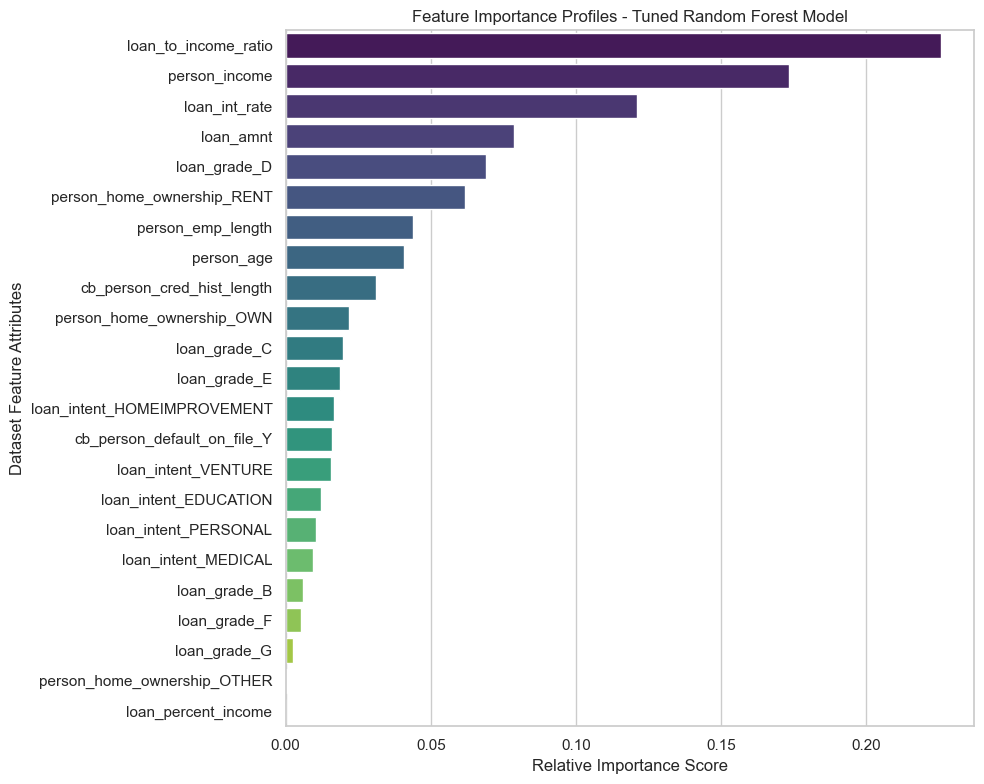

--- RANKED FEATURE IMPORTANCE SCORES ---
                    Feature  Importance
       loan_to_income_ratio    0.225856
              person_income    0.173325
              loan_int_rate    0.120910
                  loan_amnt    0.078619
               loan_grade_D    0.068945
 person_home_ownership_RENT    0.061767
          person_emp_length    0.043907
                 person_age    0.040892
 cb_person_cred_hist_length    0.031238
  person_home_ownership_OWN    0.021662
               loan_grade_C    0.019920
               loan_grade_E    0.018673
loan_intent_HOMEIMPROVEMENT    0.016564
cb_person_default_on_file_Y    0.015830
        loan_intent_VENTURE    0.015473
      loan_intent_EDUCATION    0.012129
       loan_intent_PERSONAL    0.010383
        loan_intent_MEDICAL    0.009364
               loan_grade_B    0.006041
               loan_grade_F    0.005418
               loan_grade_G    0.002468
person_home_ownership_OTHER    0.000614
        loan_percent_income    0.000000

In [7]:
# 1. Import the missing plotting libraries required for this cell
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a clean visual theme for the plot
sns.set_theme(style="whitegrid")

# 2. Extract feature importance values from our optimized production estimator
importances = best_rf_model.feature_importances_
feature_names = X.columns

# 3. Construct a structured DataFrame to hold features paired with their importance values
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. Generate a clean horizontal bar chart using Seaborn
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_imp_df, 
    x='Importance', 
    y='Feature', 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Feature Importance Profiles - Tuned Random Forest Model')
plt.xlabel('Relative Importance Score')
plt.ylabel('Dataset Feature Attributes')
plt.tight_layout()
plt.show()

# 5. Display the raw structured ranking for a precise numerical audit
print("--- RANKED FEATURE IMPORTANCE SCORES ---")
print(feature_imp_df.to_string(index=False))

In [8]:
# 1. Import joblib for model serialization
import joblib

# 2. Define the storage paths inside our project folder structure
model_save_path = '../saved_models/credit_scoring_rf_model.joblib'
scaler_save_path = '../saved_models/credit_scaler.joblib'

# 3. Export the frozen model and scaler objects to files
joblib.dump(best_rf_model, model_save_path)
joblib.dump(scaler, scaler_save_path)

print("--- MODEL SERIALIZATION ---")
print(f"Model successfully exported to:  {model_save_path}")
print(f"Scaler successfully exported to: {scaler_save_path}\n")
print("✅ SUCCESS! Your production assets are safely locked and saved.")

--- MODEL SERIALIZATION ---
Model successfully exported to:  ../saved_models/credit_scoring_rf_model.joblib
Scaler successfully exported to: ../saved_models/credit_scaler.joblib

✅ SUCCESS! Your production assets are safely locked and saved.
